In [6]:
from pathlib import Path
import pandas as pd
from rdkit.Chem import PandasTools
from mordred import Calculator, descriptors
from joblib import Parallel, delayed
import numpy as np
from sklearn.model_selection import cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [7]:
calc = Calculator(descriptors, ignore_3D = True)

def mol_to_feat(mol):
    names = [
        'BCUTv-1l', 'AATSC3s', 'AATS1s', 'BCUTi-1h', 'NdsN', 'MIC1',
        'ETA_epsilon_5', 'ATSC3s', 'AATS1p', 'AATS5se', 'AATS5s', 'ATSC2i',
        'MDEC-33', 'PEOE_VSA3', 'ATSC4d', 'MATS1se', 'SlogP_VSA10', 'IC2',
        'AATSC0dv', 'AATS3se', 'GATS2p', 'SlogP_VSA2', 'MATS1s', 'AATS3p', 'nH',
        'piPC9', 'ATSC4v', 'SMR_VSA4'
    ]
    res = calc(mol)
    return [res[name] for name in names]

In [8]:
file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
df1 = df.drop(columns = "SMILES")
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)
df = df.sample(frac = 1, ignore_index = True)

mols = df["ROMol"].tolist()
feats = Parallel(n_jobs = -1)(delayed(mol_to_feat)(mol) for mol in mols)
x_all = np.array(feats, dtype = np.float64)
y_all = np.array(df["Td(°C)"], dtype = np.float64)

In [9]:
rf = RandomForestRegressor(
    n_estimators = 300,
    random_state = 114514,
    n_jobs = -1
)

scores = cross_validate(
    rf, x_all, y_all, 
    cv = KFold(n_splits = 10, shuffle = True, random_state = 323922),
    scoring = ["neg_mean_squared_error", "neg_mean_absolute_error", "r2"],
    n_jobs = -1
)
rmse = ((-scores["test_neg_mean_squared_error"]) ** 0.5).mean()
mae = np.abs(scores["test_neg_mean_absolute_error"]).mean()
r2 = scores["test_r2"]
print(rmse, mae, r2.mean(), r2.std(), r2, sep = '\n')

38.98714704982156
29.044080103192567
0.6501828817739304
0.040837538798187786
[0.59712843 0.63658815 0.65236812 0.69043924 0.67742942 0.64508134
 0.66137824 0.73108965 0.58844629 0.62187995]


0.45073144181057223 37.483516715479695 47.06055243892891


,x_test,y_test,predict
796,,152.00,233.272361
239,,125.00,178.950341
460,,241.00,236.035833
303,,141.00,169.153152
1378,,187.39,180.629267
132,,158.00,157.250217
695,,315.00,254.217267
428,,124.50,198.494733
561,,132.00,207.706333
1355,,151.00,208.775867

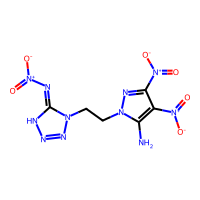
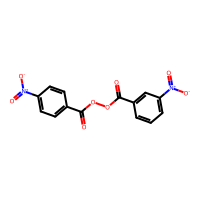
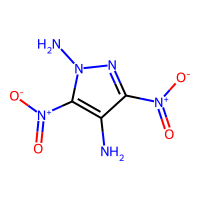
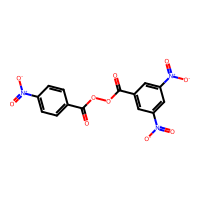
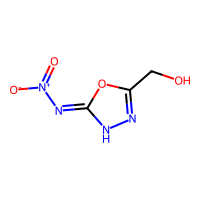
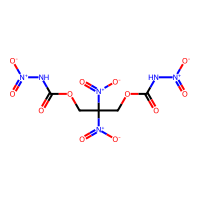
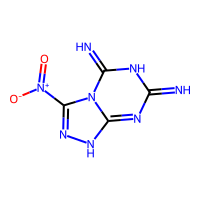
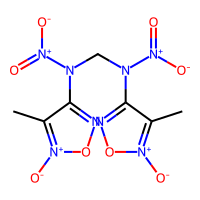
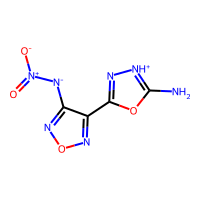
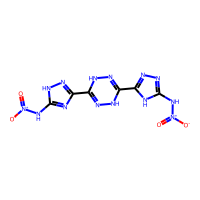
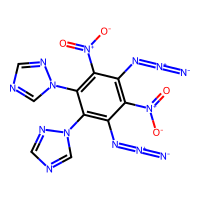
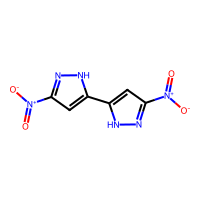
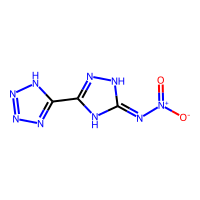
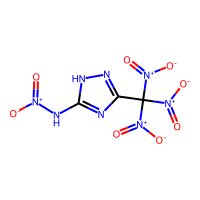
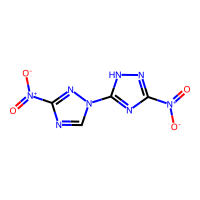
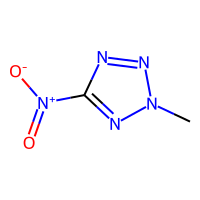
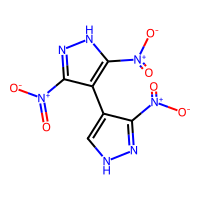
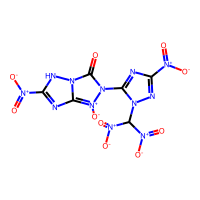
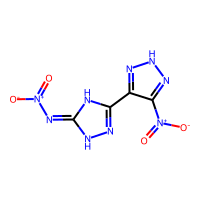
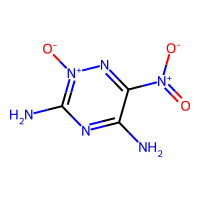
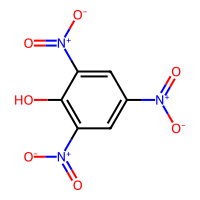
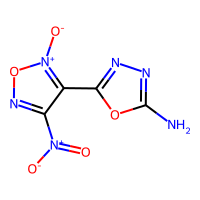
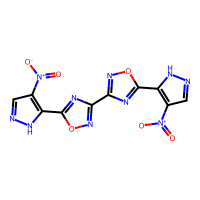
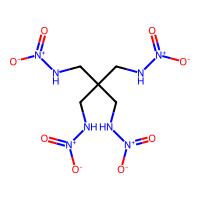
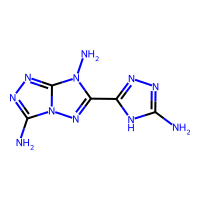
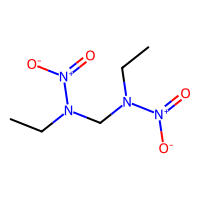
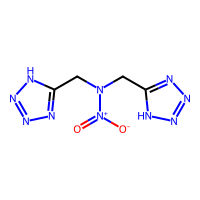
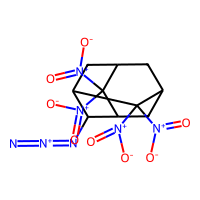
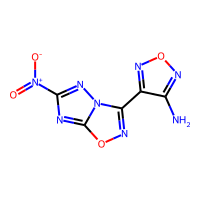
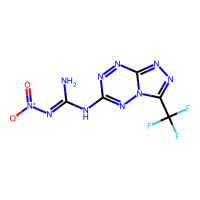

In [11]:
x_train, x_test, y_train, y_test = train_test_split(df["ROMol"], df["Td(°C)"], train_size = 0.85, test_size = 0.15)

df1 = pd.DataFrame({
    "x_test": x_test,
    "y_test": y_test
})

rf = RandomForestRegressor(
    n_estimators = 300,
    n_jobs = -1,
    random_state = 114514
)

x_train = Parallel(n_jobs = -1)(delayed(mol_to_feat)(mol) for mol in x_train)
x_train = StandardScaler().fit_transform(x_train)
x_test = Parallel(n_jobs = -1)(delayed(mol_to_feat)(mol) for mol in x_test)
x_test = StandardScaler().fit_transform(x_test)

rf.fit(x_train, y_train)
y_pre = rf.predict(x_test)

PandasTools.RenderImagesInAllDataFrames(images = True)
df1["predict"] = y_pre
print(r2_score(y_test, y_pre), mean_absolute_error(y_test, y_pre), mean_squared_error(y_test, y_pre) ** 0.5)
df1[ : 30]